In [ ]:
import numpy as np
import pandas as pd
from goodpoints import compress
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn import metrics
import time

# coreset sizes for double pp_kt() and for pp_kt()

In [2]:
def coreset_size_compresspp_kt(n):
    """
    A function to calculate the coreset size for a given n, after usage of compresspp_kt()
    """
    power = int(np.floor(np.log(n) / np.log(4)))
    n_prime = 4 ** power
    return int(np.sqrt(n_prime))

def coreset_size_double_pp_kt(n):
    """
    A function to calculate the coreset size for a given n, after usage of double_pp_kt()
    """
    ppkt_1 = coreset_size_compresspp_kt(n)
    ppkt_2 = coreset_size_compresspp_kt(n-ppkt_1)
    return ppkt_1 + ppkt_2

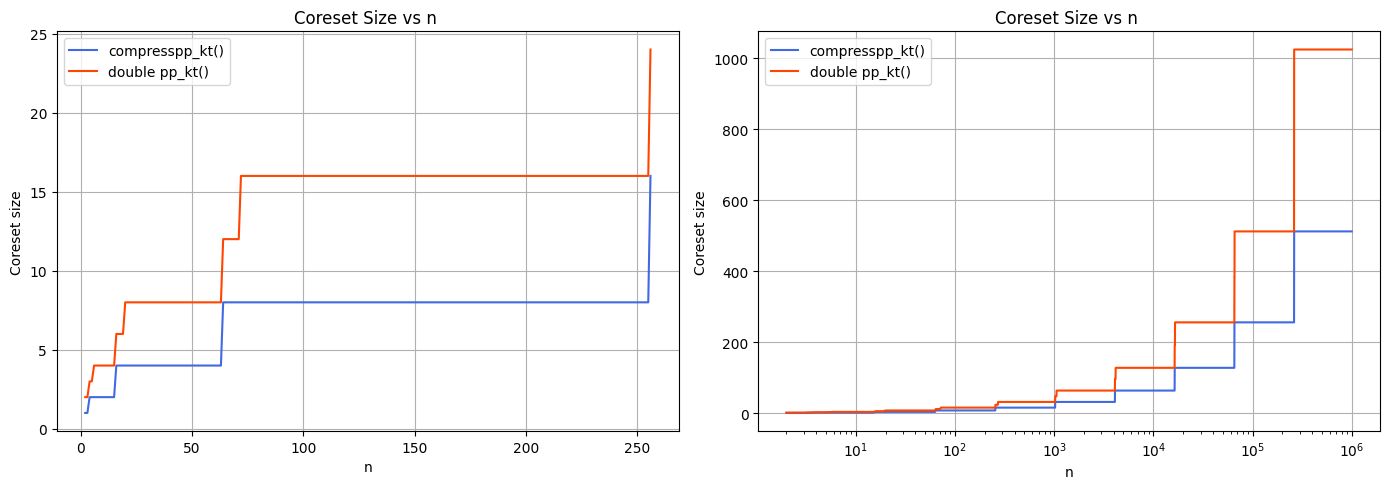

In [3]:
n_values1 = np.arange(2, 256 + 1)
n_values2 = np.arange(2, 1_000_000 + 1)

coreset_ppkt1 = [coreset_size_compresspp_kt(n) for n in n_values1]
coreset_double_ppkt1 = [coreset_size_double_pp_kt(n) for n in n_values1]

coreset_ppkt2 = [coreset_size_compresspp_kt(n) for n in n_values2]
coreset_double_ppkt2 = [coreset_size_double_pp_kt(n) for n in n_values2]

# Plot both graphs side-by-side
fig, axs = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

axs[0].plot(n_values1, coreset_ppkt1, label='compresspp_kt()', linewidth=1.5, color='royalblue')
axs[0].plot(n_values1, coreset_double_ppkt1, label='double pp_kt()', linewidth=1.5, color = "orangered")
axs[0].set_title('Coreset Size vs n ')
axs[0].set_xlabel('n')
axs[0].set_ylabel('Coreset size')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(n_values2, coreset_ppkt2, label='compresspp_kt()', linewidth=1.5, color='royalblue')
axs[1].plot(n_values2, coreset_double_ppkt2, label='double pp_kt()', linewidth=1.5, color = "orangered")
axs[1].set_title('Coreset Size vs n ')
axs[1].set_xlabel('n')
axs[1].set_xscale('log')
axs[1].set_ylabel('Coreset size')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


# wrapped_pp_kt()

In [68]:
seed = 42
n = 10_000
d = 20 # number of features (informative + redundant)
sigma = np.sqrt(2 * d)
gamma = 1 / (sigma**2) # for MMD calculation

# synthetic data
X, y = make_classification(
    n_samples = n, 
    n_features = d,   
    n_informative = int(d * 0.5),
    n_classes = 5,
    random_state = 42
)

In [73]:
def wrapped_pp_kt(X, times, sigma):
    X_current = X.copy()
    coreset_indices = np.array([], dtype=int) 
    original_indices = np.arange(X.shape[0])

    for i in range(times):
        if X_current.shape[0] <= 2:
            break
        id = compress.compress_kt(X_current, kernel_type=b"gaussian", k_params=np.array([sigma**2]))
        coreset_indices = np.concatenate([coreset_indices, original_indices[id]])

        X_current = np.delete(X_current, id, axis=0)
        original_indices = np.delete(original_indices, id, axis=0)

    return X[coreset_indices.astype(int)]

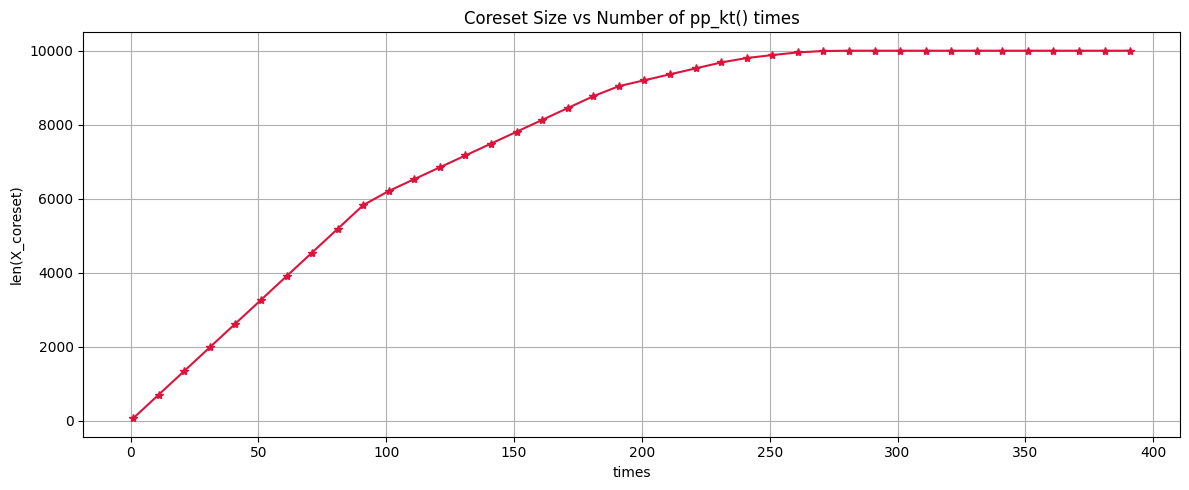

In [74]:
times_range = range(1, 401, 10)
lens = []

for times in times_range:
    coreset = wrapped_pp_kt(X, times, sigma)
    lens.append(len(coreset))

plt.figure(figsize=(12, 5))
plt.plot(times_range, lens, marker='*', color = "crimson")
plt.xlabel("times")
plt.ylabel("len(X_coreset)")
plt.title("Coreset Size vs Number of pp_kt() times")
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
def d_mmd(X, Y, gamma):
    """ 
    source: https://github.com/jindongwang/transferlearning/blob/master/code/distance/mmd_numpy_sklearn.py
    MMD using rbf (gaussian) kernel (i.e., k(x,y) = exp(-gamma * ||x-y||^2))
    """
    XX = metrics.pairwise.rbf_kernel(X, X, gamma)
    YY = metrics.pairwise.rbf_kernel(Y, Y, gamma)
    XY = metrics.pairwise.rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

In [ ]:
times_range = range(1, 50, 1)
repeat = 33  
results = []

for times in times_range:
    for r in range(repeat):
        # wrapped_pp_kt
        coreset = wrapped_pp_kt(X, times, sigma)
        mmd = d_mmd(X, coreset, gamma=gamma)
        results.append({
            "method": "wrapped_pp_kt",
            "repeat": r,
            "times": times,
            "mmd": mmd,
            "coreset_size": len(coreset), 
        })

        # iid
        coreset = X[np.random.choice(X.shape[0], size=len(coreset), replace=False)]
        mmd = d_mmd(X, coreset, gamma=gamma)
        results.append({
            "method": "iid",
            "repeat": r,
            "times": None,
            "mmd": mmd,
            "coreset_size": len(coreset), 
        })

# compresspp_kt
for r in range(repeat):
    coreset = X[compress.compress_kt(X, kernel_type=b"gaussian", k_params=np.array([sigma**2]))]
    mmd = d_mmd(X, coreset, gamma=gamma)
    results.append({
        "method": "compresspp_kt",
        "repeat": r,
        "times": None,
        "mmd": mmd,
        "coreset_size": len(coreset), 
    })

results = pd.DataFrame(results)

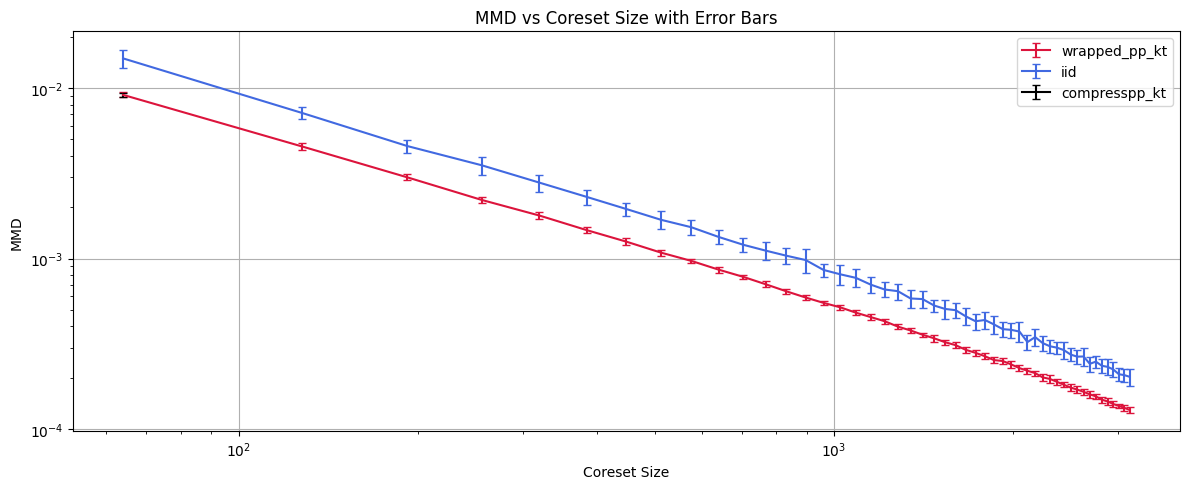

In [ ]:
import matplotlib.pyplot as plt

colors = ["crimson", "royalblue", "black"]

aggregated_results = results.groupby(["method", "coreset_size"]).agg(
    mmd_mean=("mmd", "mean"),
    mmd_std=("mmd", "std")
).reset_index()

plt.figure(figsize=(12, 5))

for i, method in enumerate(['wrapped_pp_kt', 'iid', 'compresspp_kt']):
    method_data = aggregated_results[aggregated_results["method"] == method]
    plt.errorbar(
        method_data["coreset_size"],  
        method_data["mmd_mean"],     
        yerr=method_data["mmd_std"], 
        label=method,                               
        capsize=3,                   
        linestyle='-',              
        color=colors[i % len(colors)] 
    )

plt.xlabel("Coreset Size")
plt.ylabel("MMD")
plt.title("MMD vs Coreset Size with Error Bars")
plt.legend()
plt.grid(True)
plt.xscale('log') 
plt.yscale('log')
plt.tight_layout()

plt.show()